<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_063_support_vector_machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 63/365 — Support Vector Machines (SVM)

SVM tries to separate classes using a decision boundary with the widest useful margin.

The closest points to the boundary are called **support vectors**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


## 1. Simple 2D example


In [2]:
X_demo,y_demo=make_blobs(
    n_samples=120,
    centers=2,
    cluster_std=1.2,
    random_state=42
)

demo_model=SVC(kernel="linear",C=1)
demo_model.fit(X_demo,y_demo)

print("Support vectors:",len(demo_model.support_vectors_))


Support vectors: 3


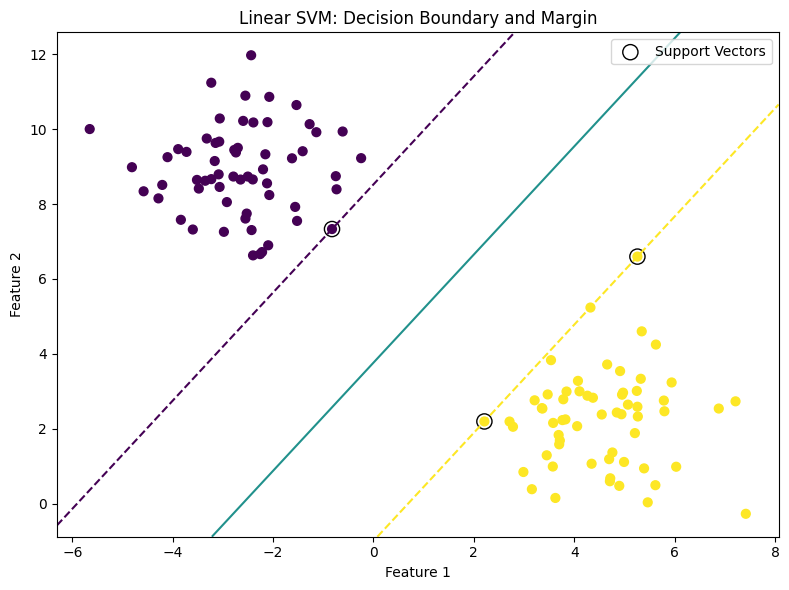

In [3]:
plt.figure(figsize=(8,6))
plt.scatter(X_demo[:,0],X_demo[:,1],c=y_demo,s=40)

ax=plt.gca()
xlim=ax.get_xlim()
ylim=ax.get_ylim()

xx=np.linspace(xlim[0],xlim[1],200)
yy=np.linspace(ylim[0],ylim[1],200)
YY,XX=np.meshgrid(yy,xx)

grid=np.vstack([XX.ravel(),YY.ravel()]).T
Z=demo_model.decision_function(grid).reshape(XX.shape)

ax.contour(
    XX,YY,Z,
    levels=[-1,0,1],
    linestyles=["--","-","--"]
)

ax.scatter(
    demo_model.support_vectors_[:,0],
    demo_model.support_vectors_[:,1],
    s=120,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.title("Linear SVM: Decision Boundary and Margin")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()


## 2. What are we seeing?

- Middle line = decision boundary
- Dashed lines = margin
- Circled points = support vectors

SVM tries to maximize the margin while still classifying the data well.


## 3. Train SVM on a real dataset

We use:

`StandardScaler → Linear SVM`


In [4]:
data=load_breast_cancer(as_frame=True)
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42,stratify=y
)

svm_model=Pipeline([
    ("scaler",StandardScaler()),
    ("svm",SVC(kernel="linear",C=1))
])

svm_model.fit(X_train,y_train)
pred=svm_model.predict(X_test)

print("Test Accuracy:",round(accuracy_score(y_test,pred),3))
print(classification_report(
    y_test,
    pred,
    target_names=data.target_names,
    digits=3
))


Test Accuracy: 0.986
              precision    recall  f1-score   support

   malignant      0.981     0.981     0.981        53
      benign      0.989     0.989     0.989        90

    accuracy                          0.986       143
   macro avg      0.985     0.985     0.985       143
weighted avg      0.986     0.986     0.986       143



## 4. What does C do?

`C` controls the trade-off between:

- wider margin
- fewer training errors

Smaller C:
- allows more mistakes
- prefers a wider, simpler margin

Larger C:
- penalizes mistakes more strongly
- can fit the training data more aggressively


In [5]:
c_values=[0.01,0.1,1,10,100]
scores=[]

for c in c_values:
    model=Pipeline([
        ("scaler",StandardScaler()),
        ("svm",SVC(kernel="linear",C=c))
    ])
    model.fit(X_train,y_train)
    scores.append(
        accuracy_score(
            y_test,
            model.predict(X_test)
        )
    )

results=pd.DataFrame({
    "C":c_values,
    "Test Accuracy":scores
})

display(results.round(3))


,C,Test Accuracy
0,0.01,0.958
1,0.10,0.986
2,1.00,0.986
3,10.00,0.965
4,100.00,0.937


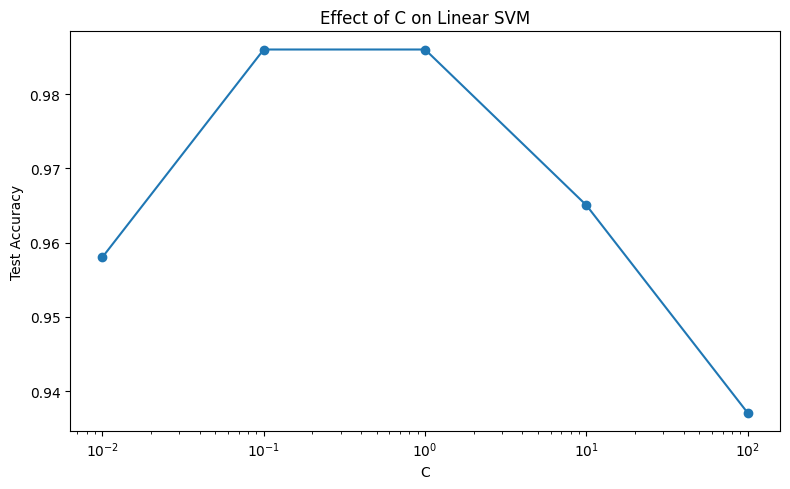

In [6]:
plt.figure(figsize=(8,5))
plt.semilogx(
    results["C"],
    results["Test Accuracy"],
    marker="o"
)
plt.xlabel("C")
plt.ylabel("Test Accuracy")
plt.title("Effect of C on Linear SVM")
plt.tight_layout()
plt.show()


## Why scaling matters

SVM depends on geometry and distances.

If one feature has a much larger numeric range than another, it can dominate the decision boundary.

That is why scaling is commonly used before SVM.


## Enterprise intuition

SVM can work well for:

- text classification
- document categorization
- image classification with engineered features
- biomedical classification
- risk classification

It is especially useful on small-to-medium datasets with many features.


## Limitation

A linear SVM creates a linear boundary.

Real datasets are often nonlinear.

That leads to one of SVM's most famous ideas:

**The Kernel Trick**

That is the next topic.


## What does this teach?

- SVM finds a separating boundary between classes.
- It maximizes the margin.
- Support vectors define the critical edge of that margin.
- Scaling matters.
- `C` controls the margin-vs-training-error trade-off.
- Kernels extend SVM to nonlinear problems.

> **SVM is not only trying to separate the classes — it tries to separate them with the widest useful margin.**


## References

- https://scikit-learn.org/stable/modules/svm.html
- https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- https://link.springer.com/article/10.1007/BF00994018
